[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/iamjamesbowden/AG952/blob/main/assignments/march2026/AG952_Assignment_2026.ipynb)

# AG952 | Coursework Assignment 2026

**Textual Analytics for Accounting and Finance**  
University of Strathclyde Business School

---

This notebook serves three purposes: it allocates you to one of four research scenarios based on your student number; it provides the data loading and analytical infrastructure required to complete the analysis; and it records your methodological choices to a central log so that the module team can monitor approach diversity across the cohort. All analytical decisions and their justifications are your own. Your written report must explain and defend every choice made within this notebook, with explicit reference to the methodological literature.

Before you begin, save a personal copy of this notebook to your Google Drive (File > Save a copy in Drive) or to a personal GitHub repository. Do not modify the shared repository copy. Work only from your personal copy throughout the assignment.

**Release date:** 10 March 2026  
**Submission deadline:** 1 April 2026

---

> ## ⚠ What you must submit
>
> Your written report must include **all** of the following outputs from this notebook. These are not optional — missing outputs will be penalised.
>
> | Output | Produced in |
> |---|---|
> | Classification metrics table and confusion matrix | Step 6a or 6b |
> | Sentiment score table (companies × years) | Step 6c |
> | Secondary metric score table (companies × years) | Step 9 |
> | Sentiment chart (trend over time + distribution by category) | Step 10 |
> | Secondary metric chart | Step 10 |
> | Manual validation sample (50 sentences with human and automated labels) | Step 11 |
> | Methodological choices summary table | Step 13 |
>
> Each table and chart must be accompanied in your report by a substantive written discussion. It is not sufficient to paste a table or chart without interpreting it with reference to your research question.
>
> To copy a table from the notebook output, use the plain-text version printed below each displayed table — select the text, copy, and paste into your document.
>
> You are also encouraged to create additional tables or visualisations beyond those listed above. The outputs generated by the notebook represent the minimum required. If disaggregating the data in a different way — by firm, category, section, year range, or any other dimension — would add richness to your analysis and strengthen your discussion, you are free to do so.

In [22]:
#@title Step 0 -- Clone the AG952 repository (run this first)

import os
import subprocess

REPO_URL = "https://github.com/iamjamesbowden/AG952.git"
REPO_DIR = "AG952"

if not os.path.exists(REPO_DIR):
    print("Cloning AG952 repository...")
    result = subprocess.run(["git", "clone", REPO_URL], capture_output=True, text=True)
    if result.returncode == 0:
        print("Repository cloned successfully.")
    else:
        print("Clone failed:")
        print(result.stderr)
else:
    print("Repository already present. Pulling latest changes...")
    result = subprocess.run(["git", "-C", REPO_DIR, "pull", "origin", "main"],
                            capture_output=True, text=True)
    print(result.stdout.strip() or "Already up to date.")

os.chdir(REPO_DIR)
print(f"Working directory: {os.getcwd()}")

Cloning AG952 repository...
Repository cloned successfully.
Working directory: /content/AG952/AG952/AG952


In [24]:
#@title Configuration -- set APPS_SCRIPT_URL before running

# Paste the deployed Apps Script web app URL here before running the notebook.
# Leave as an empty string if the endpoint has not yet been deployed.
APPS_SCRIPT_URL = "https://script.google.com/macros/s/AKfycbyrv8mSp2e2OpH4nqclZbmTNaRBO_xjMWoc1A8_0Y6bOwk6qfWlXnqH6HCtGpPigXDS/exec"

# Paths -- do not modify
# CORPUS_PATH is set dynamically in the Load Corpus cell after scenario allocation.
CORPUS_BASE_PATH  = "assignments/march2026/data"     # do not modify
LM_DICT_PATH      = "assignments/march2026/data/lm_dictionary.csv"
HARVARD_DICT_PATH = "assignments/march2026/data/harvard_iv_dictionary.csv"
ALLOCATION_PATH   = "assignments/march2026/student_allocations.csv"
SEED_LABELS_PATH  = "assignments/march2026/nb_seed_labels.csv"

In [25]:
#@title Step 1 -- Install and import dependencies

!pip install requests pandas numpy matplotlib seaborn scikit-learn nltk -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os
import json
import time
import warnings
import requests
import random

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)
nltk.download("wordnet", quiet=True)

warnings.filterwarnings("ignore")

print("Dependencies loaded successfully.")

Dependencies loaded successfully.


## Scenario Allocation

Each student is assigned to one of four research scenarios based on their student number. The scenario determines which corpus and research question you will work with throughout the assignment. You must not change your allocated scenario.

**What to do:**
1. Run the cell below (click the ▶ play button to the left of it, or press Shift+Enter).
2. An input box will appear **at the bottom of the cell output** — scroll down if you do not see it immediately.
3. Type your student number and press **Enter**.
4. Your allocated scenario and research question will be displayed.

In [26]:
#@title Step 2 -- Enter your student number to receive your scenario allocation

SCENARIOS = {
    "A": {
        "id": "A",
        "title": "Climate and ESG Risk Language in the US Energy Sector (2019-2023)",
        "question": (
            "How have the sentiment and thematic characteristics of climate and "
            "ESG-related risk disclosures evolved across fossil fuel and renewable "
            "energy firms in their 10-K filings between 2019 and 2023, and to what "
            "extent do these patterns diverge systematically between firm types?"
        ),
        "corpus_note": (
            "138 10-K filings from 30 firms across three energy sub-sectors: "
            "12 oil and gas producers, 10 integrated utilities, and 8 pure-play "
            "renewables. Filing years span 2019-2023, though not every firm "
            "has a filing in every year."
        ),
    },
    "B": {
        "id": "B",
        "title": "Narrative Predictors of Corporate Financial Distress (2015-2023)",
        "question": (
            "Do the linguistic features of 10-K filings in the one to three years preceding "
            "a bankruptcy filing differ systematically from those of matched non-distressed "
            "peers, and can those features be used to train a reliable text-based classifier "
            "of financial distress?"
        ),
        "corpus_note": (
            "175 10-K filings from 38 firms: 18 distressed firms (filings from the years "
            "preceding bankruptcy) matched to 20 non-distressed peers by SIC code and "
            "asset quintile. Filing years span 2015-2022."
        ),
    },
    "C": {
        "id": "C",
        "title": "Risk Disclosure and the 2023 US Regional Banking Crisis",
        "question": (
            "Did the risk disclosures in 10-K filings from US regional banks in the period "
            "2020-2022 provide investors with meaningful warning of the vulnerabilities that "
            "materialised during the March 2023 banking crisis, and how does the language "
            "of subsequently failed banks compare to that of survivors?"
        ),
        "corpus_note": (
            "159 10-K filings from 37 US banks across four categories: 3 subsequently "
            "failed banks, 7 stressed survivors, 18 unaffected regional banks, and "
            "9 large systemic institutions. Filing years span 2019-2023, though not "
            "every firm has a filing in every year."
        ),
    },
    "D": {
        "id": "D",
        "title": "Supply Chain Risk Disclosure Before and After COVID-19 (2019-2022)",
        "question": (
            "How did the language of supply chain risk disclosure in 10-K filings change "
            "across manufacturing and logistics-intensive firms in the two years before and "
            "the two years after the onset of the COVID-19 pandemic, and does the degree "
            "of linguistic change vary with firms' ex post supply chain vulnerability?"
        ),
        "corpus_note": (
            "175 10-K filings from 38 firms across five supply-chain-intensive sectors: "
            "6 automotive, 5 consumer electronics, 13 industrial manufacturing, "
            "7 logistics, and 7 retail. Filing years span 2019-2023, though not every "
            "firm has a filing in every year."
        ),
    }
}

# Modulo mapping for fallback allocation
MODULO_MAP = {0: "A", 1: "B", 2: "C", 3: "D"}


print("An input box will appear below. Type your student number and press Enter.")
print("(Scroll down if you do not see it immediately.)")
print()
STUDENT_ID = input("Student number: ").strip()


def allocate_scenario(student_id, allocation_path, modulo_map):
    """
    Look up student_id in the allocation CSV.
    Falls back to int(student_id) % 4 if the student ID is not found.
    Returns a scenario key: "A", "B", "C", or "D".
    """
    try:
        df = pd.read_csv(allocation_path, dtype=str)
        df["student_id"] = df["student_id"].str.strip()
        match = df[df["student_id"] == student_id.strip()]
        if not match.empty:
            return match.iloc[0]["scenario"].strip().upper(), "allocation file"
    except FileNotFoundError:
        print(f"Warning: allocation file not found at {allocation_path}.")
    except Exception as ex:
        print(f"Warning: could not read allocation file ({ex}).")

    # Fallback: modulo allocation
    try:
        numeric_id = int("".join(filter(str.isdigit, student_id)))
        scenario = modulo_map[numeric_id % 4]
        return scenario, "modulo fallback (student ID not found in allocation file)"
    except Exception:
        return "A", "default fallback (student ID could not be parsed)"


ASSIGNED_SCENARIO_KEY, ALLOCATION_METHOD = allocate_scenario(
    STUDENT_ID, ALLOCATION_PATH, MODULO_MAP
)
SCENARIO = SCENARIOS[ASSIGNED_SCENARIO_KEY]

print("\n" + "=" * 60)
print(f"  Student ID:  {STUDENT_ID}")
print(f"  Scenario:    {SCENARIO['id']} -- {SCENARIO['title']}")
print(f"  Allocated via: {ALLOCATION_METHOD}")
print("=" * 60)
print(f"\nResearch question:\n{SCENARIO['question']}")
print(f"\nCorpus:\n{SCENARIO['corpus_note']}")
print(
    "\nSelect your analytical methods in Steps 4-8. Every choice must be "
    "justified in your report with explicit reference to your research "
    "question and the methodological literature."
)
print("\nDo not change your allocated scenario. Record it in your report.")

An input box will appear below. Type your student number and press Enter.
(Scroll down if you do not see it immediately.)

Student number: 202562697

  Student ID:  202562697
  Scenario:    B -- Narrative Predictors of Corporate Financial Distress (2015-2023)
  Allocated via: allocation file

Research question:
Do the linguistic features of 10-K filings in the one to three years preceding a bankruptcy filing differ systematically from those of matched non-distressed peers, and can those features be used to train a reliable text-based classifier of financial distress?

Corpus:
175 10-K filings from 38 firms: 18 distressed firms (filings from the years preceding bankruptcy) matched to 20 non-distressed peers by SIC code and asset quintile. Filing years span 2015-2022.

Select your analytical methods in Steps 4-8. Every choice must be justified in your report with explicit reference to your research question and the methodological literature.

Do not change your allocated scenario. Record

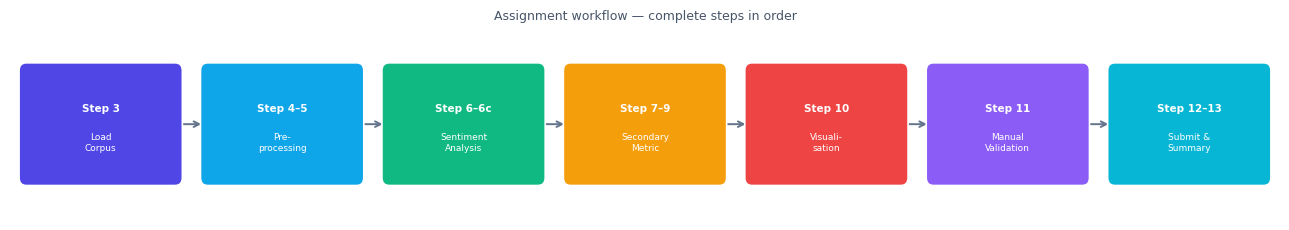

In [27]:
#@title Assignment workflow

def _draw_workflow_diagram():
    """Render the assignment step workflow as a horizontal pipeline."""
    import matplotlib.patches as mpatches
    import matplotlib.pyplot as plt

    stages = [
        ("3",     "Load\nCorpus"),
        ("4\u20135",  "Pre-\nprocessing"),
        ("6\u20136c", "Sentiment\nAnalysis"),
        ("7\u20139",  "Secondary\nMetric"),
        ("10",    "Visuali-\nsation"),
        ("11",    "Manual\nValidation"),
        ("12\u201313","Submit &\nSummary"),
    ]
    colours = ["#4f46e5", "#0ea5e9", "#10b981", "#f59e0b", "#ef4444", "#8b5cf6", "#06b6d4"]

    fig, ax = plt.subplots(figsize=(13, 2.4))
    ax.set_xlim(0, len(stages))
    ax.set_ylim(0, 1)
    ax.axis("off")
    bw, bh, by = 0.82, 0.56, 0.22

    for i, ((code, label), col) in enumerate(zip(stages, colours)):
        cx = i + 0.5
        rect = mpatches.FancyBboxPatch(
            (cx - bw / 2, by), bw, bh,
            boxstyle="round,pad=0.04", linewidth=1.2,
            edgecolor="white", facecolor=col, zorder=3)
        ax.add_patch(rect)
        ax.text(cx, by + bh / 2 + 0.08, f"Step {code}",
                ha="center", va="center",
                fontsize=7.5, fontweight="bold", color="white", zorder=4)
        ax.text(cx, by + bh / 2 - 0.10, label,
                ha="center", va="center",
                fontsize=6.5, color="white", zorder=4, linespacing=1.3)
        if i < len(stages) - 1:
            ax.annotate("", xy=(i + 1 + 0.5 - bw / 2 - 0.02, by + bh / 2),
                        xytext=(cx + bw / 2 + 0.02, by + bh / 2),
                        arrowprops=dict(arrowstyle="->", color="#64748b", lw=1.4),
                        zorder=2)

    ax.set_title("Assignment workflow \u2014 complete steps in order",
                 fontsize=9, color="#475569", pad=6)
    plt.tight_layout()
    plt.show()

_draw_workflow_diagram()

In [28]:
#@title Step 3 -- Load the corpus

# The corpus contains two sections for each firm and year:
#
#   item_1a  --  Risk Factors
#   item_7   --  Management's Discussion and Analysis (MD&A)
#
# Use the dropdown below to select which section(s) you will analyse.
# Your choice has direct consequences for which linguistic phenomena are
# captured and must be justified in your report with reference to the
# literature and your scenario's research question.

import ipywidgets as widgets
from IPython.display import display

CORPUS_PATH = os.path.join(
    CORPUS_BASE_PATH,
    f"scenario_{ASSIGNED_SCENARIO_KEY.lower()}",
    "corpus.csv"
)

try:
    _raw_corpus = pd.read_csv(CORPUS_PATH)
    print(f"Corpus loaded from: {CORPUS_PATH}")
    print(f"Raw shape: {_raw_corpus.shape[0]} rows x {_raw_corpus.shape[1]} columns")
    print(f"Columns:   {list(_raw_corpus.columns)}")
    print(f"Firms:     {_raw_corpus['firm'].nunique()}")
    print(f"Years:     {sorted(_raw_corpus['year'].unique())}")
    print(f"Sections:  {sorted(_raw_corpus['section'].unique())}")
    print()
except FileNotFoundError:
    print(f"ERROR: corpus not found at {CORPUS_PATH}.")
    print("Run `git pull origin main` to ensure the data files are present.")
    _raw_corpus = None

w_section = widgets.Dropdown(
    options=[
        "Both sections combined (full narrative)",
        "item_1a \u2014 Risk Factors only",
        "item_7 \u2014 MD\u0026A only",
    ],
    description="Corpus section:",
    style={"description_width": "200px"},
    layout=widgets.Layout(width="520px"),
)

_section_out = widgets.Output()

def _apply_section(_change=None):
    global corpus
    if _raw_corpus is None:
        return
    _section_out.clear_output(wait=True)
    with _section_out:
        if w_section.value == "item_1a \u2014 Risk Factors only":
            corpus = _raw_corpus[_raw_corpus["section"] == "item_1a"].copy()
        elif w_section.value == "item_7 \u2014 MD\u0026A only":
            corpus = _raw_corpus[_raw_corpus["section"] == "item_7"].copy()
        else:
            # Combine both sections into one row per firm-year
            _agg = {"text": " ".join}
            if "word_count" in _raw_corpus.columns:
                _agg["word_count"] = "sum"
            corpus = (_raw_corpus
                      .groupby(["firm", "category", "year"], as_index=False)
                      .agg(_agg))
            corpus["section"] = "combined"

        print(f"Section selection applied: {w_section.value}")
        print(f"Working corpus: {corpus.shape[0]} rows x {corpus.shape[1]} columns")
        print(f"Firms: {corpus['firm'].nunique()} | "
              f"Years: {sorted(corpus['year'].unique())}")
        print()
        print("This choice is recorded and submitted with your other")
        print("methodological decisions when you run Step 12.")

w_section.observe(_apply_section, names="value")

print("Select the corpus section you will analyse, then continue to Step 4.")
display(w_section, _section_out)
_apply_section()

Corpus loaded from: assignments/march2026/data/scenario_b/corpus.csv
Raw shape: 338 rows x 11 columns
Columns:   ['cik', 'firm', 'ticker', 'category', 'year', 'section', 'filing_date', 'accession_number', 'text', 'word_count', 'bk_year']
Firms:     38
Years:     [np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022)]
Sections:  ['item_1a', 'item_7']

Select the corpus section you will analyse, then continue to Step 4.


Dropdown(description='Corpus section:', layout=Layout(width='520px'), options=('Both sections combined (full n…

Output()

## Pre-processing

You must select a cleaning pipeline that prepares the raw 10-K text for downstream analysis and justify every decision in your report with reference to relevant literature, including lecture slides and supporting class activities, core reading and external reading. Five decisions are required, each with direct consequences for the validity of your results. Choices made without theoretical justification will be penalised in the marking scheme.

| Decision | What the choice affects |
|---|---|
| Case folding | Whether all tokens are lowercased prior to analysis; affects dictionary matching, topic model vocabulary, and the distinction between proper nouns and common words |
| Stop-word list | Which words are excluded from the token set prior to analysis |
| Stemming vs. lemmatisation | How inflected word forms are handled; affects vocabulary size and the mapping of related terms |
| Number handling | Whether numeric tokens are retained in, removed from, or replaced within the token set |
| TF-IDF weighting | Whether term frequencies are adjusted by their rarity across the corpus before scoring |

**What to do:**
1. **Run Step 4.** Five dropdown menus will appear. Use them to record your pre-processing choices — the selections are saved automatically as you change them.
2. **Run Step 5.** This applies your choices to the corpus. The first 30 tokens of a sample document are printed so you can verify the pipeline is working as expected.

In [29]:
#@title Step 4 -- Record your pre-processing decisions

!pip install ipywidgets -q

import ipywidgets as widgets
from IPython.display import display

w_case_folding = widgets.Dropdown(
    options=["Yes — lowercase all tokens", "No — preserve original case"],
    description="Case folding:",
    style={"description_width": "200px"},
    layout=widgets.Layout(width="500px")
)
w_stopwords = widgets.Dropdown(
    options=["Standard NLTK stopwords",
             "Finance-adjusted (modal verbs and negation retained)"],
    description="Stop-word list:",
    style={"description_width": "200px"},
    layout=widgets.Layout(width="500px")
)
w_normalisation = widgets.Dropdown(
    options=["Lemmatisation (WordNetLemmatizer)", "Stemming (PorterStemmer)", "None"],
    description="Normalisation:",
    style={"description_width": "200px"},
    layout=widgets.Layout(width="500px")
)
w_numbers = widgets.Dropdown(
    options=["Remove all numeric tokens", "Retain as-is",
             "Replace with placeholder <NUM>"],
    description="Number handling:",
    style={"description_width": "200px"},
    layout=widgets.Layout(width="500px")
)
w_tfidf = widgets.Dropdown(
    options=["Yes -- apply TF-IDF weighting", "No -- use raw term counts"],
    description="TF-IDF weighting:",
    style={"description_width": "200px"},
    layout=widgets.Layout(width="500px")
)

# Live confirmation panel -- updates immediately when any dropdown changes
_out = widgets.Output()

def _show_selections(_change=None):
    _out.clear_output(wait=True)
    with _out:
        print("Choices recorded:")
        print(f"  Case folding:     {w_case_folding.value}")
        print(f"  Stop-word list:   {w_stopwords.value}")
        print(f"  Normalisation:    {w_normalisation.value}")
        print(f"  Number handling:  {w_numbers.value}")
        print(f"  TF-IDF weighting: {w_tfidf.value}")
        print()
        print("These values are stored in the Python session. They take effect")
        print("once you implement preprocess() in Step 5, and are submitted to")
        print("the module log when you run Step 13.")

for _w in [w_case_folding, w_stopwords, w_normalisation, w_numbers, w_tfidf]:
    _w.observe(_show_selections, names="value")

display(w_case_folding, w_stopwords, w_normalisation, w_numbers, w_tfidf, _out)
_show_selections()  # show initial state immediately

Dropdown(description='Case folding:', layout=Layout(width='500px'), options=('Yes — lowercase all tokens', 'No…

Dropdown(description='Stop-word list:', layout=Layout(width='500px'), options=('Standard NLTK stopwords', 'Fin…

Dropdown(description='Normalisation:', layout=Layout(width='500px'), options=('Lemmatisation (WordNetLemmatize…

Dropdown(description='Number handling:', layout=Layout(width='500px'), options=('Remove all numeric tokens', '…

Dropdown(description='TF-IDF weighting:', layout=Layout(width='500px'), options=('Yes -- apply TF-IDF weightin…

Output()

In [30]:
#@title Step 5 -- Apply pre-processing pipeline

import re
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer, PorterStemmer

# Modal verbs and negation retained under the finance-adjusted stop-word list
_FINANCE_RETAIN = {
    "no", "not", "nor", "neither", "never", "none",
    "can", "cannot", "could", "may", "might",
    "shall", "should", "will", "would", "must"
}

# Regex for tokens that are purely numeric (digits, commas, decimals, signs, currency symbols)
_NUM_RE = re.compile(r'^[\d,.\-\+%$£€]+$')


def preprocess(text: str) -> list:
    """
    Clean and tokenise a single document string using the choices
    selected in Step 4.

    Pipeline (in order):
      1. Tokenise with NLTK word_tokenize.
      2. Case folding       -- controlled by w_case_folding.value.
      3. Number handling    -- controlled by w_numbers.value.
      4. Remove punctuation-only tokens.
      5. Stop-word removal  -- controlled by w_stopwords.value.
      6. Normalisation      -- controlled by w_normalisation.value.

    TF-IDF weighting (w_tfidf.value) is a corpus-level operation applied
    in Steps 6a and 6b; it is not part of single-document tokenisation.
    """
    # 1. Tokenise
    tokens = word_tokenize(str(text))

    # 2. Case folding
    if w_case_folding.value == "Yes — lowercase all tokens":
        tokens = [t.lower() for t in tokens]

    # 3. Number handling
    if w_numbers.value == "Remove all numeric tokens":
        tokens = [t for t in tokens if not _NUM_RE.match(t)]
    elif w_numbers.value == "Replace with placeholder <NUM>":
        tokens = ["<NUM>" if _NUM_RE.match(t) else t for t in tokens]
    # "Retain as-is" -- no change

    # 4. Remove punctuation-only tokens (preserve <NUM> placeholder)
    tokens = [t for t in tokens if t == "<NUM>" or re.search(r'[a-zA-Z]', t)]

    # 5. Stop-word removal (compare lowercase regardless of case folding choice,
    #    so common words are still removed even when case is preserved)
    _stop = set(stopwords.words("english"))
    if w_stopwords.value == "Finance-adjusted (modal verbs and negation retained)":
        _stop = _stop - _FINANCE_RETAIN
    tokens = [t for t in tokens if t.lower() not in _stop]

    # 6. Normalisation
    if w_normalisation.value == "Lemmatisation (WordNetLemmatizer)":
        _lem = WordNetLemmatizer()
        tokens = [_lem.lemmatize(t) for t in tokens]
    elif w_normalisation.value == "Stemming (PorterStemmer)":
        _stem = PorterStemmer()
        tokens = [_stem.stem(t) for t in tokens]
    # "None" -- no change

    return tokens


# Test on the first row of the corpus
try:
    sample_text = corpus["text"].iloc[0] if "text" in corpus.columns else ""
    tokens = preprocess(sample_text)
    print("Pre-processing applied successfully.")
    print(f"  Case folding:     {w_case_folding.value}")
    print(f"  Stop-word list:   {w_stopwords.value}")
    print(f"  Normalisation:    {w_normalisation.value}")
    print(f"  Number handling:  {w_numbers.value}")
    print(f"  TF-IDF weighting: {w_tfidf.value} (applied at corpus level in Steps 6a/6b)")
    print(f"\nSample document: {len(tokens)} tokens after pre-processing.")
    print(f"First 30 tokens:  {tokens[:30]}")
except NameError:
    print("corpus is not yet defined -- run Step 3 first, then re-run this cell.")

Pre-processing applied successfully.
  Case folding:     Yes — lowercase all tokens
  Stop-word list:   Standard NLTK stopwords
  Normalisation:    Lemmatisation (WordNetLemmatizer)
  Number handling:  Remove all numeric tokens
  TF-IDF weighting: Yes -- apply TF-IDF weighting (applied at corpus level in Steps 6a/6b)

Sample document: 17432 tokens after pre-processing.
First 30 tokens:  ['global', 'manufacturer', 'marketer', 'distributor', 'high', 'performance', 'coating', 'system', 'operate', 'business', 'environment', 'includes', 'risk', 'risk', 'unlike', 'risk', 'faced', 'recent', 'past', 'unlike', 'risk', 'faced', 'competitor', 'event', 'contemplated', 'following', 'discussion', 'risk', 'occur', 'business']


## Sentiment Analysis

You must apply one sentiment engine to the corpus and justify your choice in the report on at least three criteria: transparency of the underlying word list or model weights; domain specificity of the method to the text being analysed; and computational requirements relative to the corpus size. Three approaches are available.

The **Loughran-McDonald (LM) dictionary** and **Harvard General Inquirer (Harvard IV)** are word-list approaches in which sentiment is measured by matching pre-processed tokens against fixed positive and negative word sets. Both dictionaries were constructed from different source corpora and reflect different theoretical assumptions about what constitutes sentiment in text. When you select `lm_dictionary`, an uncertainty word count is computed automatically alongside the sentiment scores.

The **Naive Bayes** classifier is a supervised method trained on the pre-labelled sentences provided in `nb_seed_labels.csv`. Rather than producing hard categorical labels, the classifier computes a **net probability score** — P(Positive) − P(Negative) — which lies in the same [−1, +1] range as the dictionary score. This means the same classification thresholds apply to both approaches.

**Classification thresholds** are set in Step 6 and apply to all students, regardless of method. A continuous score — whether from a dictionary or a classifier — must be converted into a categorical label (Positive / Neutral / Negative) for evaluation, tabulation, and manual validation. If the neutral zone is too narrow, almost every sentence will be labelled Positive or Negative even when the signal is weak; if it is too wide, genuinely positive or negative sentences will be misclassified as Neutral. You must justify your chosen thresholds in your report.

**What to do:**
1. **Run Step 6.** A dropdown will appear — select your sentiment model. Set your positive and negative classification thresholds using the inputs that appear below the dropdown.
2. **Run Step 6a** if you chose `lm_dictionary` or `harvard_iv`. The corpus is scored and evaluated against seed labels automatically. **Skip Step 6b.**
3. **Run Step 6b** if you chose `naive_bayes`. The classifier trains, computes net probability scores, and evaluates against seed labels automatically. **Skip Step 6a.**
4. **Run Step 6c** to produce the sentiment score table for your report.

In [31]:
#@title Step 6 -- Select your sentiment model and set classification thresholds

w_sentiment = widgets.Dropdown(
    options=["lm_dictionary", "harvard_iv", "naive_bayes"],
    description="Sentiment model:",
    style={"description_width": "200px"},
    layout=widgets.Layout(width="500px")
)

# Classification thresholds -- apply to ALL sentiment methods.
#
# For dictionary methods (lm_dictionary, harvard_iv):
#   dict_score is a continuous value in [-1, +1] computed as:
#   (positive word count - negative word count) / (positive + negative)
#
# For machine learning methods (naive_bayes):
#   A net probability score is computed as P(Positive) - P(Negative),
#   which also lies in [-1, +1]. This captures the classifier's relative
#   confidence in a positive versus negative assessment.
#
# In both cases the same conversion rule applies:
#   score >= positive threshold  →  Positive
#   score <= negative threshold  →  Negative
#   everything in between        →  Neutral
#
# Notice that scores are rarely exactly 0, so without a neutral zone
# almost every document will be labelled Positive or Negative regardless
# of how weak the signal actually is. You must justify your thresholds.

w_pos_threshold = widgets.BoundedFloatText(
    value=0.10, min=0.0, max=1.0, step=0.01,
    description="Positive threshold (\u2265):",
    style={"description_width": "210px"},
    layout=widgets.Layout(width="380px")
)
w_neg_threshold = widgets.BoundedFloatText(
    value=-0.10, min=-1.0, max=0.0, step=0.01,
    description="Negative threshold (\u2264):",
    style={"description_width": "210px"},
    layout=widgets.Layout(width="380px")
)


def _score_to_label(score):
    """
    Convert a continuous sentiment score to a categorical label using the
    thresholds set above. Used by Steps 6a, 6b, and 11.
    """
    if pd.isna(score):
        return "Neutral"
    if score >= w_pos_threshold.value:
        return "Positive"
    if score <= w_neg_threshold.value:
        return "Negative"
    return "Neutral"


print("Select your sentiment model and set your classification thresholds.")
print("  Dictionary approaches (LM or Harvard IV)    \u2192 run Step 6a")
print("  Naive Bayes classifier                       \u2192 run Step 6b")
display(w_sentiment, w_pos_threshold, w_neg_threshold)

Select your sentiment model and set your classification thresholds.
  Dictionary approaches (LM or Harvard IV)    → run Step 6a
  Naive Bayes classifier                       → run Step 6b


Dropdown(description='Sentiment model:', layout=Layout(width='500px'), options=('lm_dictionary', 'harvard_iv',…

BoundedFloatText(value=0.1, description='Positive threshold (≥):', layout=Layout(width='380px'), max=1.0, step…

BoundedFloatText(value=-0.1, description='Negative threshold (≤):', layout=Layout(width='380px'), max=0.0, min…

In [32]:
#@title Step 6a -- Dictionary sentiment (LM or Harvard IV)

# Run this cell if w_sentiment.value is "lm_dictionary" or "harvard_iv".
# Skip it if you chose a classifier approach; run Step 6b instead.

if w_sentiment.value in ("lm_dictionary", "harvard_iv"):

    dict_path = LM_DICT_PATH if w_sentiment.value == "lm_dictionary" else HARVARD_DICT_PATH

    try:
        d = pd.read_csv(dict_path)
        positive_words    = set(d[d["Positive"]    != 0]["Word"].str.lower())
        negative_words    = set(d[d["Negative"]    != 0]["Word"].str.lower())
        uncertainty_words = (set(d[d["Uncertainty"] != 0]["Word"].str.lower())
                             if "Uncertainty" in d.columns else set())
        unc_note = f", {len(uncertainty_words)} uncertainty" if uncertainty_words else ""
        print(f"{w_sentiment.value} loaded: "
              f"{len(positive_words)} positive, {len(negative_words)} negative{unc_note}.")
    except FileNotFoundError:
        print(f"ERROR: dictionary not found at {dict_path}.")
        print("Run `git pull origin main` to ensure data files are present.")
        positive_words, negative_words, uncertainty_words = set(), set(), set()


    def dict_sentiment(text, pos_words, neg_words, unc_words):
        """
        Compute dictionary sentiment scores for a single document.
        Returns a dict with pos_count, neg_count, net_sentiment,
        sentiment_score (continuous, -1 to +1), and unc_count.
        """
        try:
            _tokens = preprocess(str(text))
            tokens = [t.lower() for t in _tokens] if _tokens else \
                     [t.lower() for t in str(text).split()]
        except Exception:
            tokens = [t.lower() for t in str(text).split()]

        pos   = sum(1 for t in tokens if t in pos_words)
        neg   = sum(1 for t in tokens if t in neg_words)
        unc   = sum(1 for t in tokens if t in unc_words)
        denom = pos + neg
        score = (pos - neg) / denom if denom > 0 else np.nan
        return {"pos_count": pos, "neg_count": neg,
                "net_sentiment": pos - neg, "sentiment_score": score,
                "unc_count": unc}


    # Score the full corpus
    if "text" in corpus.columns and positive_words:
        results = corpus["text"].apply(
            lambda t: dict_sentiment(t, positive_words, negative_words, uncertainty_words)
        )
        corpus["dict_pos"]   = results.apply(lambda r: r["pos_count"])
        corpus["dict_neg"]   = results.apply(lambda r: r["neg_count"])
        corpus["dict_net"]   = results.apply(lambda r: r["net_sentiment"])
        corpus["dict_score"] = results.apply(lambda r: r["sentiment_score"])
        if uncertainty_words:
            corpus["dict_unc"] = results.apply(lambda r: r["unc_count"])
        print("Dictionary sentiment scores computed.")
        display(corpus[["dict_pos", "dict_neg", "dict_score"]].describe())


    # -------------------------------------------------------------------------
    # Evaluate dictionary accuracy against seed labels
    # -------------------------------------------------------------------------
    # The thresholds set in Step 6 are used here. Adjusting them in Step 6
    # will automatically update the confusion matrix below.
    # -------------------------------------------------------------------------

    try:
        _seed = pd.read_csv(SEED_LABELS_PATH)
        _seed_scores = _seed["sentence"].apply(
            lambda t: dict_sentiment(t, positive_words, negative_words, uncertainty_words)
        )
        _seed["dict_score"] = _seed_scores.apply(lambda r: r["sentiment_score"])

        print("\n" + "-" * 60)
        print("Sentiment score distribution across seed sentences:")
        print("(Use this to inform your threshold choices in Step 6.)")
        print("-" * 60)
        display(_seed["dict_score"].describe().to_frame().T.round(4))

        _eval_out = widgets.Output()

        def _run_evaluation(_change=None):
            _eval_out.clear_output(wait=True)
            with _eval_out:
                pos_t = w_pos_threshold.value
                neg_t = w_neg_threshold.value
                label_order = ["Positive", "Neutral", "Negative"]

                _seed["predicted_label"] = _seed["dict_score"].apply(_score_to_label)

                print(f"Thresholds: Positive \u2265 {pos_t:+.2f} | "
                      f"Negative \u2264 {neg_t:+.2f} | "
                      f"Neutral: {neg_t:+.2f} to {pos_t:+.2f}")
                print(f"n = {len(_seed)} seed sentences\n")

                print("Predicted label distribution:")
                display(_seed["predicted_label"].value_counts().to_frame())

                # Classification metrics (without support column)
                _rep = classification_report(
                    _seed["label"], _seed["predicted_label"],
                    labels=label_order, output_dict=True, zero_division=0
                )
                _rep_df = (pd.DataFrame(_rep).T
                           .loc[label_order, ["precision", "recall", "f1-score"]]
                           .round(3))
                _rep_df.columns = ["Precision", "Recall", "F1"]
                print("\nClassification metrics (dictionary vs. human seed labels):")
                display(_rep_df)

                # Confusion matrix -- displayed and printed for easy copy-paste
                cm = confusion_matrix(
                    _seed["label"], _seed["predicted_label"], labels=label_order
                )
                cm_df = pd.DataFrame(cm, index=label_order, columns=label_order)
                cm_df.index.name   = "Actual"
                cm_df.columns.name = "Predicted"
                print("\nConfusion matrix:")
                display(cm_df)
                print(cm_df.to_string())

        # Connect to the shared threshold widgets defined in Step 6
        w_pos_threshold.observe(_run_evaluation, names="value")
        w_neg_threshold.observe(_run_evaluation, names="value")

        print("\nThe confusion matrix updates automatically when you adjust")
        print("the thresholds in Step 6 above.")
        display(_eval_out)
        _run_evaluation()

    except FileNotFoundError:
        print(f"\nNote: seed labels not found at {SEED_LABELS_PATH} -- evaluation skipped.")

else:
    print(f"Skipping Step 6a: sentiment model is '{w_sentiment.value}'. Run Step 6b instead.")

lm_dictionary loaded: 354 positive, 2355 negative, 297 uncertainty.
Dictionary sentiment scores computed.


,dict_pos,dict_neg,dict_score
count,175.00000,175.000000,174.000000
mean,185.92000,492.754286,-0.463600
std,139.17757,346.555932,0.131912
min,0.00000,0.000000,-0.768293
25%,82.00000,262.000000,-0.547952
50%,166.00000,409.000000,-0.457463
75%,225.50000,627.000000,-0.366432
max,651.00000,2153.000000,-0.169811



------------------------------------------------------------
Sentiment score distribution across seed sentences:
(Use this to inform your threshold choices in Step 6.)
------------------------------------------------------------


,count,mean,std,min,25%,50%,75%,max
dict_score,151.0,-0.1534,0.938,-1.0,-1.0,-1.0,1.0,1.0



The confusion matrix updates automatically when you adjust
the thresholds in Step 6 above.


Output()

In [ ]:
#@title Step 6b -- ML classifier sentiment (Naive Bayes)

# Run this cell if w_sentiment.value is "naive_bayes".
# Skip it if you chose a dictionary approach; run Step 6a instead.
#
# The classifier computes a net probability score: P(Positive) - P(Negative),
# which lies in [-1, +1] and is directly comparable to the dictionary score.
# The thresholds set in Step 6 are then applied to categorise each document.
#
# Evaluation uses 5-fold stratified cross-validation across all 286 seed
# sentences, giving unbiased performance estimates without discarding data.
# The final model is then trained on all seed sentences for corpus application.

from sklearn.model_selection import cross_val_predict, StratifiedKFold

if w_sentiment.value == "naive_bayes":

    try:
        seed_labels = pd.read_csv(SEED_LABELS_PATH)
        print(f"Seed labels loaded: {seed_labels.shape[0]} sentences")
        display(seed_labels["label"].value_counts().to_frame())
    except FileNotFoundError:
        print(f"ERROR: seed labels not found at {SEED_LABELS_PATH}.")
        print("Run `git pull origin main` to ensure data files are present.")
        seed_labels = None

    if seed_labels is not None:

        # Vectorise all seed sentences
        vectorizer = TfidfVectorizer(max_features=5000)
        X = vectorizer.fit_transform(seed_labels["sentence"])
        y = seed_labels["label"]

        # Class order is consistent across folds (sorted alphabetically by sklearn)
        _all_classes = sorted(y.unique())   # ["Negative", "Neutral", "Positive"]
        _pos_idx_cv  = _all_classes.index("Positive") if "Positive" in _all_classes else 2
        _neg_idx_cv  = _all_classes.index("Negative") if "Negative" in _all_classes else 0

        # 5-fold stratified cross-validation for unbiased evaluation
        # (uses all 286 seed sentences; each sentence is predicted exactly once
        #  by a model that was not trained on it)
        _cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        _clf_eval = MultinomialNB()

        _probs_cv = cross_val_predict(_clf_eval, X, y, cv=_cv, method="predict_proba")
        _net_cv   = _probs_cv[:, _pos_idx_cv] - _probs_cv[:, _neg_idx_cv]
        y_pred_cv = [_score_to_label(s) for s in _net_cv]

        label_order = ["Positive", "Neutral", "Negative"]
        print(f"Classifier: {w_sentiment.value}")
        print(f"Evaluation: 5-fold cross-validation (n = {len(y)} seed sentences)")
        print(f"Thresholds: Positive \u2265 {w_pos_threshold.value:+.2f} | "
              f"Negative \u2264 {w_neg_threshold.value:+.2f}")

        # Classification metrics (without support column)
        _rep = classification_report(
            y, y_pred_cv, labels=label_order, output_dict=True, zero_division=0
        )
        _rep_df = (pd.DataFrame(_rep).T
                   .loc[label_order, ["precision", "recall", "f1-score"]]
                   .round(3))
        _rep_df.columns = ["Precision", "Recall", "F1"]
        print("\nClassification metrics (cross-validated):")
        display(_rep_df)

        # Confusion matrix -- displayed and printed for easy copy-paste
        cm = confusion_matrix(y, y_pred_cv, labels=label_order)
        cm_df = pd.DataFrame(cm, index=label_order, columns=label_order)
        cm_df.index.name   = "Actual"
        cm_df.columns.name = "Predicted"
        print("\nConfusion matrix (cross-validated):")
        display(cm_df)
        print(cm_df.to_string())

        # Train final model on ALL seed sentences for corpus application
        clf = _clf_eval
        clf.fit(X, y)
        _classes = list(clf.classes_)
        _pos_idx = _classes.index("Positive") if "Positive" in _classes else _pos_idx_cv
        _neg_idx = _classes.index("Negative") if "Negative" in _classes else _neg_idx_cv

        # Apply to the full corpus
        corpus_vectors     = vectorizer.transform(corpus["text"].fillna(""))
        _probs_corpus      = clf.predict_proba(corpus_vectors)
        corpus["ml_score"] = (_probs_corpus[:, _pos_idx]
                              - _probs_corpus[:, _neg_idx])
        corpus["ml_sentiment"] = corpus["ml_score"].apply(_score_to_label)

        print("\nNet probability score (ml_score) statistics across corpus:")
        display(corpus["ml_score"].describe().to_frame().T.round(4))
        print("\nSentiment label distribution (threshold-based):")
        display(corpus["ml_sentiment"].value_counts().to_frame())

else:
    print(f"Skipping Step 6b: sentiment model is '{w_sentiment.value}'. Run Step 6a instead.")

In [33]:
#@title Step 6c -- Sentiment score table

# This cell pivots your sentiment scores into a company x year matrix.
# Run it after Step 6a or Step 6b has completed successfully.

_df = corpus

score_col = ("dict_score" if "dict_score" in _df.columns else
             "ml_score"   if "ml_score"   in _df.columns else None)

if score_col is None:
    print("No sentiment scores found in the corpus. Run Step 6a or Step 6b first.")
else:
    pivot = (_df
             .pivot_table(index=["firm", "category"],
                          columns="year",
                          values=score_col,
                          aggfunc="mean")
             .round(4))

    pivot = pivot.reset_index()
    pivot.columns.name = None
    year_cols = sorted([c for c in pivot.columns if c not in ("firm", "category")])
    pivot = pivot[["firm", "category"] + year_cols]
    pivot.rename(columns={"firm": "Firm", "category": "Industry"}, inplace=True)

    print(f"Sentiment scores ({w_sentiment.value}) \u2014 companies as rows, years as columns")
    print(f"Score column: {score_col} | "
          f"Positive \u2265 {w_pos_threshold.value:+.2f} | "
          f"Negative \u2264 {w_neg_threshold.value:+.2f}")
    display(pivot)

    pivot.to_csv("sentiment_scores.csv", index=False)
    print("sentiment_scores.csv saved \u2014 download from the Colab file browser.")

    # LM uncertainty scores (computed automatically when lm_dictionary is selected)
    if "dict_unc" in _df.columns:
        unc_pivot = (_df
                     .pivot_table(index=["firm", "category"],
                                  columns="year",
                                  values="dict_unc",
                                  aggfunc="mean")
                     .round(1)
                     .reset_index())
        unc_pivot.columns.name = None
        year_cols_u = sorted([c for c in unc_pivot.columns if c not in ("firm", "category")])
        unc_pivot = unc_pivot[["firm", "category"] + year_cols_u]
        unc_pivot.rename(columns={"firm": "Firm", "category": "Industry"}, inplace=True)
        print("\nUncertainty word counts (LM) \u2014 companies as rows, years as columns")
        display(unc_pivot)
        unc_pivot.to_csv("sentiment_scores_uncertainty.csv", index=False)
        print("sentiment_scores_uncertainty.csv saved \u2014 download from the Colab file browser.")

    print()
    print("=" * 65)
    print("  ASSESSMENT SUBMISSION REQUIRED")
    print("  You must include the table(s) above in your written report.")
    print("  Each table must be accompanied by a written discussion that")
    print("  interprets the results with reference to your research question.")
    print("=" * 65)

Sentiment scores (lm_dictionary) — companies as rows, years as columns
Score column: dict_score | Positive ≥ +0.10 | Negative ≤ -0.10


,Firm,Industry,2015,2016,2017,2018,2019,2020,2021,2022
0,Albertsons,control,NaN,-0.5341,-0.5208,-0.5235,-0.5881,-0.5402,-0.5158,-0.5676
1,Avis Budget Group,control,NaN,-0.4362,-0.3988,-0.3702,-0.3626,-0.4298,-0.4444,-0.4185
2,Briggs and Stratton,control,NaN,-0.3759,-0.3814,-0.3946,-0.4515,-0.4746,-0.3700,-0.3875
3,California Resources,distressed,NaN,NaN,-0.3285,-0.5108,-0.5655,NaN,NaN,NaN
4,Callon Petroleum,control,NaN,-0.3362,-0.3571,-0.3252,-0.3786,-0.4554,-0.3439,-0.3295
5,Chesapeake Energy,distressed,NaN,NaN,-0.6787,-0.6116,NaN,NaN,NaN,NaN
6,Denbury Resources,distressed,NaN,NaN,-0.4977,-0.4421,-0.5481,NaN,NaN,NaN
7,Devon Energy,control,NaN,-0.6446,-0.6494,-0.6777,-0.7143,-0.6863,-0.7255,-0.7683
8,Dollar General,control,NaN,NaN,-0.3662,-0.4282,-0.3728,-0.4076,-0.4047,-0.4463
9,Dollar Tree,control,NaN,-0.7193,-0.7168,-0.7302,-0.7236,-0.7123,-0.5410,-0.6219


sentiment_scores.csv saved — download from the Colab file browser.

Uncertainty word counts (LM) — companies as rows, years as columns


,Firm,Industry,2015,2016,2017,2018,2019,2020,2021,2022
0,Albertsons,control,NaN,737.0,716.0,704.0,675.0,642.0,631.0,644.0
1,Avis Budget Group,control,NaN,112.0,122.0,125.0,127.0,145.0,158.0,151.0
2,Briggs and Stratton,control,NaN,178.0,426.0,441.0,551.0,64.0,682.0,665.0
3,California Resources,distressed,NaN,NaN,379.0,422.0,399.0,NaN,NaN,NaN
4,Callon Petroleum,control,NaN,131.0,136.0,130.0,110.0,99.0,97.0,97.0
5,Chesapeake Energy,distressed,NaN,NaN,341.0,367.0,NaN,NaN,NaN,NaN
6,Denbury Resources,distressed,NaN,NaN,357.0,368.0,385.0,NaN,NaN,NaN
7,Devon Energy,control,NaN,193.0,184.0,207.0,195.0,217.0,229.0,235.0
8,Dollar General,control,NaN,NaN,554.0,590.0,389.0,434.0,403.0,409.0
9,Dollar Tree,control,NaN,93.0,94.0,106.0,101.0,125.0,142.0,145.0


sentiment_scores_uncertainty.csv saved — download from the Colab file browser.

  ASSESSMENT SUBMISSION REQUIRED
  You must include the table(s) above in your written report.
  Each table must be accompanied by a written discussion that
  interprets the results with reference to your research question.


## Secondary Metric

You must supplement your sentiment analysis with one secondary metric and explain in your report what incremental information it provides that sentiment alone cannot. Three options are scaffolded: the Gunning Fog readability index (Li, 2008), which captures disclosure complexity and has been linked to earnings persistence; year-on-year cosine similarity (Brown and Tucker, 2011), which distinguishes substantive revision from boilerplate repetition; and Latent Dirichlet Allocation, which identifies latent thematic structure without requiring a predefined vocabulary. Your choice should be theoretically motivated by your scenario's research question, with reference to relevant literature, including lecture slides and supporting class activities, core reading and external reading.

**If you select LDA**, you must also choose the number of topics the model should identify. This is a critical methodological decision. Too few topics produces broad, overlapping themes that may not capture meaningful distinctions in the corpus; too many produces highly specific topics that are difficult to interpret and may overfit to noise. There is no universally correct number — it depends on the size and diversity of your corpus and your research question. Common practice is to experiment across a range of values and select the number that produces topics that are both coherent and substantively interpretable. You must justify your chosen number of topics in your report.

**What to do:**
1. **Run Step 7.** A dropdown will appear — select your secondary metric. If you choose LDA, additional inputs will appear for the number of topics and topic labels (fill the labels in after Step 8).
2. **Run Step 8.** The selected metric is computed and applied to the corpus automatically. LDA may take a minute or two to fit. Once Step 8 has finished, **return to Step 7** and fill in the topic labels based on the top words printed in the output.
3. **Run Step 9** to produce the score table for your report.

In [34]:
#@title Step 7 -- Select your secondary metric

w_secondary = widgets.Dropdown(
    options=["fog_index", "cosine_similarity", "lda"],
    description="Secondary metric:",
    style={"description_width": "200px"},
    layout=widgets.Layout(width="500px")
)

w_lda_topics = widgets.BoundedIntText(
    value=10, min=2, max=50, step=1,
    description="Number of topics:",
    style={"description_width": "200px"},
    layout=widgets.Layout(width="380px")
)

# Container for the dynamically generated topic name text boxes
_topic_name_widgets = []
_topic_names_box    = widgets.VBox([])

def _build_topic_name_widgets(_change=None):
    """Rebuild the topic name inputs whenever the topic count changes."""
    global _topic_name_widgets
    n = w_lda_topics.value
    _topic_name_widgets = [
        widgets.Text(
            value=f"Topic {i}",
            description=f"Topic {i} name:",
            style={"description_width": "120px"},
            layout=widgets.Layout(width="400px")
        )
        for i in range(n)
    ]
    _topic_names_box.children = _topic_name_widgets

w_lda_topics.observe(_build_topic_name_widgets, names="value")
_build_topic_name_widgets()   # populate with default 10 topics on load

_lda_panel = widgets.VBox([
    widgets.HTML(value=(
        "<div style='margin-top:10px; padding:12px 14px; background:#1e3a5f; "
        "color:#f8fafc; border-left:4px solid #3b82f6; border-radius:4px; "
        "font-size:13px; line-height:1.6;'>"
        "<b style='font-size:14px;'>LDA settings</b><br><br>"
        "<b>Number of topics:</b> How many distinct themes should the model identify? "
        "Values between 5 and 20 are typical for corpora of this size. Run Step 8, "
        "read the top words printed for each topic, then return here and adjust "
        "the count if the topics are not coherent or meaningful. "
        "You must justify your final choice in your report."
        "<br><br>"
        "<b>Topic names:</b> After running Step 8, read the top words for each "
        "topic printed in the output and give each one a short descriptive label "
        "(e.g. <i>Regulatory Risk</i>, <i>Operational Performance</i>). "
        "These labels replace the raw topic numbers in the Step 9 score table, "
        "making it interpretable. You must discuss what each topic represents "
        "and why it is meaningful for your research question."
        "</div>"
    )),
    w_lda_topics,
    widgets.HTML(value="<b>Topic labels</b> (fill in after running Step 8):"),
    _topic_names_box,
])

_step7_out = widgets.Output()

def _update_step7(_change=None):
    _step7_out.clear_output(wait=True)
    with _step7_out:
        if w_secondary.value == "lda":
            display(_lda_panel)
        print(f"\nSelected: {w_secondary.value}"
              + (f"  |  Topics: {w_lda_topics.value}" if w_secondary.value == "lda" else ""))
        print("Run Step 8 to apply this metric to the corpus.")

w_secondary.observe(_update_step7, names="value")
w_lda_topics.observe(_update_step7, names="value")

display(w_secondary, _step7_out)
_update_step7()

Dropdown(description='Secondary metric:', layout=Layout(width='500px'), options=('fog_index', 'cosine_similari…

Output()

In [35]:
#@title Step 8 -- Secondary metric

# Install gensim if LDA was selected
if w_secondary.value == "lda":
    import subprocess
    subprocess.run(["pip", "install", "gensim", "-q"], capture_output=True)
    print("gensim installed.")


def gunning_fog(text: str) -> float:
    """
    Gunning Fog Index = 0.4 x (avg sentence length + % complex words).
    Complex words: 3 or more syllables.
    Reference: Li (2008), Journal of Accounting and Economics.
    """
    sentences = [s.strip() for s in re.split(r'[.!?]+', str(text)) if s.strip()]
    if not sentences:
        return np.nan
    words = re.findall(r'\b[a-zA-Z]+\b', str(text))
    if not words:
        return np.nan

    def _syllables(word):
        word = word.lower().rstrip('e')
        return max(1, len(re.findall(r'[aeiouy]+', word)))

    avg_sent_len = len(words) / len(sentences)
    pct_complex  = 100 * sum(1 for w in words if _syllables(w) >= 3) / len(words)
    return round(0.4 * (avg_sent_len + pct_complex), 2)


def cosine_year_on_year(text_year_t: str, text_year_t1: str) -> float:
    """
    TF-IDF cosine similarity between two texts from consecutive years.
    Returns a float in [0, 1]; values near 1 indicate minimal revision.
    Reference: Brown and Tucker (2011), Journal of Accounting Research.
    """
    try:
        vec   = TfidfVectorizer()
        tfidf = vec.fit_transform([str(text_year_t), str(text_year_t1)])
        return round(float(cosine_similarity(tfidf[0:1], tfidf[1:2])[0][0]), 4)
    except Exception:
        return np.nan


def run_lda(texts: list, n_topics: int = 10) -> tuple:
    """
    Fit an LDA model to pre-processed texts.
    Returns: (lda_model, topic_word_matrix, document_topic_matrix)
    Reference: Grimmer et al. (2022), Text as Data, Ch. 13.
    """
    from gensim import corpora
    from gensim.models import LdaModel

    tokenised  = [preprocess(t) for t in texts]
    dictionary = corpora.Dictionary(tokenised)
    dictionary.filter_extremes(no_below=5, no_above=0.5)
    bow_corpus = [dictionary.doc2bow(t) for t in tokenised]

    lda_model = LdaModel(
        bow_corpus, num_topics=n_topics,
        id2word=dictionary, passes=10, random_state=42
    )

    doc_topics = np.zeros((len(bow_corpus), n_topics))
    for i, bow in enumerate(bow_corpus):
        for tid, prob in lda_model.get_document_topics(bow):
            doc_topics[i, tid] = prob

    return lda_model, lda_model.get_topics(), doc_topics


# --- Apply the selected metric to the corpus ---

_df = corpus

if w_secondary.value == "fog_index":
    print("Computing Gunning Fog Index...")
    corpus["fog"] = corpus["text"].apply(gunning_fog)
    print(f"Done. Mean Fog Index: {corpus['fog'].mean():.2f}")
    display(corpus["fog"].describe().to_frame())

elif w_secondary.value == "cosine_similarity":
    print("Computing year-on-year cosine similarity...")
    _agg = (_df.groupby(["firm", "category", "year"], as_index=False)
               .agg({"text": " ".join}))
    _rows = []
    for _firm, _grp in _agg.groupby("firm"):
        _grp   = _grp.sort_values("year")
        _years = list(_grp["year"])
        _cat   = _grp["category"].iloc[0]
        for i in range(len(_years) - 1):
            t, t1 = _years[i], _years[i + 1]
            txt_t  = _grp[_grp["year"] == t]["text"].values[0]
            txt_t1 = _grp[_grp["year"] == t1]["text"].values[0]
            _rows.append({
                "firm": _firm, "category": _cat,
                "year_pair": f"{t}-{t1}",
                "similarity": cosine_year_on_year(txt_t, txt_t1)
            })
    similarity_df = pd.DataFrame(_rows)
    print(f"Done. {len(similarity_df)} firm-year pairs computed.")
    display(similarity_df)

elif w_secondary.value == "lda":
    _n_topics = w_lda_topics.value
    print(f"Fitting LDA model ({_n_topics} topics) ...")
    lda_model, topic_word_matrix, document_topic_matrix = run_lda(
        list(corpus["text"].fillna("")), n_topics=_n_topics
    )
    corpus["dominant_topic"] = document_topic_matrix.argmax(axis=1)
    print(f"Done. Top words per topic ({_n_topics} topics):")
    for _i, _topic in enumerate(lda_model.print_topics(num_words=8)):
        print(f"  Topic {_i}: {_topic[1]}")

Computing Gunning Fog Index...
Done. Mean Fog Index: 19.65


,fog
count,175.000000
mean,19.649200
std,2.226657
min,14.610000
25%,17.925000
50%,19.240000
75%,21.495000
max,25.380000


In [36]:
#@title Step 9 -- Secondary metric score table

# Run this cell after Step 8 has completed.
# It pivots the secondary metric scores into a company x year table
# ready to copy into your written report.

_df = corpus

_SUBMISSION_REMINDER = (
    "\n" + "=" * 65 + "\n"
    "  ASSESSMENT SUBMISSION REQUIRED\n"
    "  You must include the table above in your written report.\n"
    "  Discuss what the scores reveal about your research question.\n"
    + "=" * 65
)

if w_secondary.value == "fog_index":

    if "fog" not in _df.columns:
        print("Fog scores not found. Run Step 8 first.")
    else:
        fog_pivot = (_df
                     .pivot_table(index=["firm", "category"],
                                  columns="year",
                                  values="fog",
                                  aggfunc="mean")
                     .round(2)
                     .reset_index())
        fog_pivot.columns.name = None
        year_cols = sorted([c for c in fog_pivot.columns if c not in ("firm", "category")])
        fog_pivot = fog_pivot[["firm", "category"] + year_cols]
        fog_pivot.rename(columns={"firm": "Firm", "category": "Industry"}, inplace=True)
        print("Gunning Fog scores \u2014 companies as rows, years as columns")
        display(fog_pivot)
        fog_pivot.to_csv("secondary_metric_fog.csv", index=False)
        print("secondary_metric_fog.csv saved \u2014 download from the Colab file browser.")
        print(_SUBMISSION_REMINDER)

elif w_secondary.value == "cosine_similarity":

    try:
        sim_pivot = (similarity_df
                     .pivot_table(index=["firm", "category"],
                                  columns="year_pair",
                                  values="similarity",
                                  aggfunc="mean")
                     .round(4)
                     .reset_index())
        sim_pivot.columns.name = None
        sim_pivot.rename(columns={"firm": "Firm", "category": "Industry"}, inplace=True)
        print("Year-on-year cosine similarity \u2014 companies as rows, year pairs as columns")
        display(sim_pivot)
        sim_pivot.to_csv("secondary_metric_cosine.csv", index=False)
        print("secondary_metric_cosine.csv saved \u2014 download from the Colab file browser.")
        print(_SUBMISSION_REMINDER)
    except NameError:
        print("similarity_df not found. Run Step 8 first.")

elif w_secondary.value == "lda":

    if "dominant_topic" not in _df.columns:
        print("LDA results not found. Run Step 8 first.")
    else:
        _topic_labels = {
            i: (w.value.strip() or f"Topic {i}")
            for i, w in enumerate(_topic_name_widgets)
        }

        lda_pivot = (_df
                     .pivot_table(index=["firm", "category"],
                                  columns="year",
                                  values="dominant_topic",
                                  aggfunc=lambda x: int(x.mode().iloc[0]) if not x.empty else -1)
                     .reset_index())
        lda_pivot.columns.name = None
        year_cols = sorted([c for c in lda_pivot.columns if c not in ("firm", "category")])

        for col in year_cols:
            lda_pivot[col] = lda_pivot[col].map(
                lambda v: _topic_labels.get(v, f"Topic {v}") if v != -1 else ""
            )

        lda_pivot = lda_pivot[["firm", "category"] + year_cols]
        lda_pivot.rename(columns={"firm": "Firm", "category": "Industry"}, inplace=True)
        print("Dominant LDA topic \u2014 companies as rows, years as columns")
        print("Topic numbers have been replaced with your labels from Step 7.")
        display(lda_pivot)
        lda_pivot.to_csv("secondary_metric_lda.csv", index=False)
        print("secondary_metric_lda.csv saved \u2014 download from the Colab file browser.")
        print(_SUBMISSION_REMINDER)

Gunning Fog scores — companies as rows, years as columns


,Firm,Industry,2015,2016,2017,2018,2019,2020,2021,2022
0,Albertsons,control,NaN,17.49,17.39,17.80,18.66,18.33,18.86,19.05
1,Avis Budget Group,control,NaN,23.92,23.50,23.72,24.01,25.38,25.35,23.84
2,Briggs and Stratton,control,NaN,18.86,19.13,19.30,20.62,17.34,17.49,17.85
3,California Resources,distressed,NaN,NaN,17.75,21.98,23.27,NaN,NaN,NaN
4,Callon Petroleum,control,NaN,23.06,23.13,22.53,22.32,22.66,22.51,22.58
5,Chesapeake Energy,distressed,NaN,NaN,22.39,22.05,NaN,NaN,NaN,NaN
6,Denbury Resources,distressed,NaN,NaN,19.09,19.24,19.71,NaN,NaN,NaN
7,Devon Energy,control,NaN,18.45,18.92,18.82,20.13,21.54,21.74,21.91
8,Dollar General,control,NaN,NaN,21.25,21.41,21.55,21.98,22.03,21.90
9,Dollar Tree,control,NaN,17.37,17.28,17.50,17.65,17.94,17.92,18.33


secondary_metric_fog.csv saved — download from the Colab file browser.

  ASSESSMENT SUBMISSION REQUIRED
  You must include the table above in your written report.
  Discuss what the scores reveal about your research question.


## Visualisation

Step 10 generates two standard figures automatically:

1. **Sentiment over time** — a line chart of mean sentiment score by year, broken down by firm category, and a box plot of the score distribution per category.
2. **Secondary metric over time** — equivalent charts for whichever secondary metric you selected in Step 7.

Both figures are saved to disk as PNG files so they can be inserted directly into your written report. Your report must include both figures, provide fully labelled captions, and discuss what each figure reveals about your research question.

**What to do:** Run Step 10. Both figures will be generated and saved automatically. To download them, open the Colab file browser (the folder icon in the left-hand panel), locate `fig1_sentiment.png` and `fig2_*.png`, right-click each file, and select **Download**.

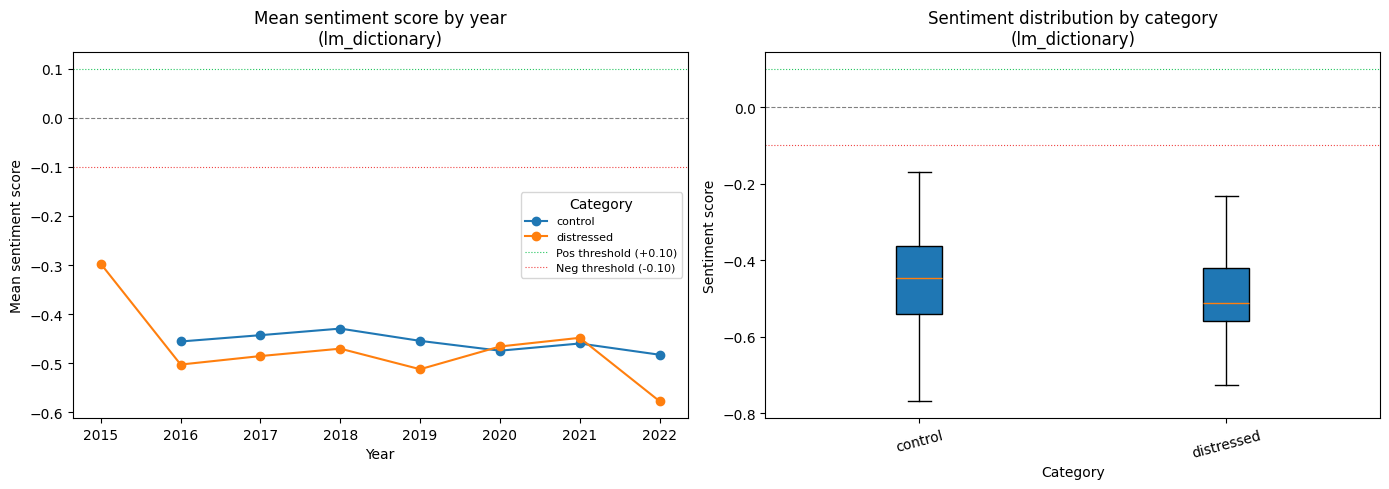

fig1_sentiment.png saved.
  ASSESSMENT SUBMISSION REQUIRED
  You must include this chart in your written report.
  Provide a fully labelled caption and a written discussion
  that interprets the figure with reference to your research question.


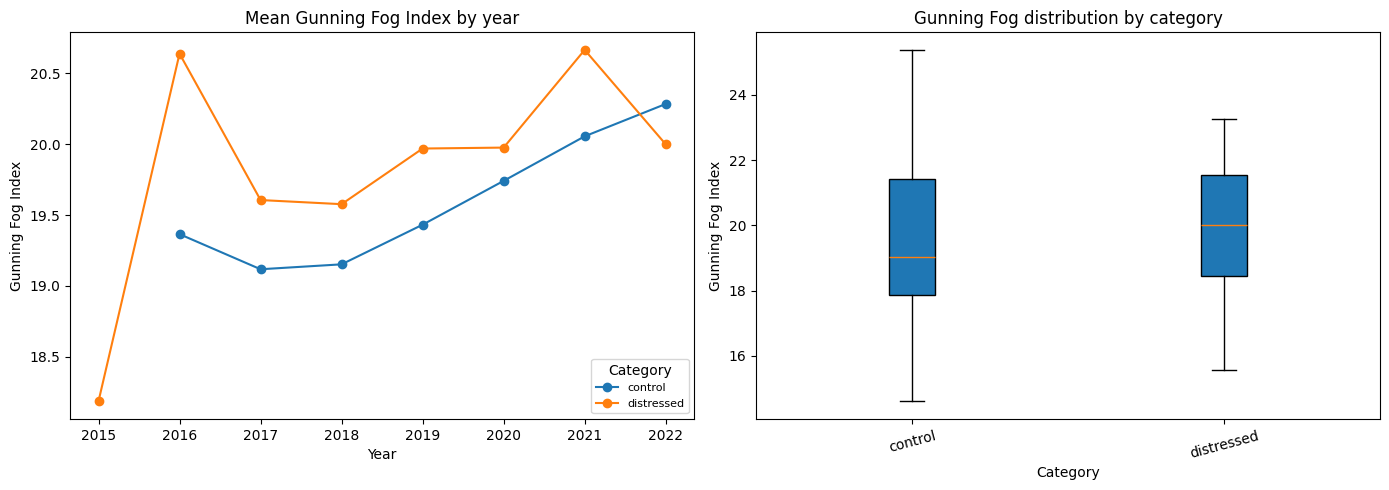

fig2_fog.png saved.
  ASSESSMENT SUBMISSION REQUIRED
  You must include this chart in your written report.
  Provide a fully labelled caption and a written discussion
  that interprets the figure with reference to your research question.


In [37]:
#@title Step 10 -- Visualisations

_df = corpus

_FIG_REMINDER = (
    "=" * 65 + "\n"
    "  ASSESSMENT SUBMISSION REQUIRED\n"
    "  You must include this chart in your written report.\n"
    "  Provide a fully labelled caption and a written discussion\n"
    "  that interprets the figure with reference to your research question.\n"
    + "=" * 65
)

# --- Figure 1: Sentiment ---

_score_col = ("dict_score" if "dict_score" in _df.columns else
              "ml_score"   if "ml_score"   in _df.columns else None)

if _score_col is None:
    print("No sentiment scores found. Run Step 6a or Step 6b first.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    yearly = _df.groupby(["year", "category"])[_score_col].mean().reset_index()
    for cat, grp in yearly.groupby("category"):
        axes[0].plot(grp["year"], grp[_score_col], marker="o", label=cat)
    axes[0].axhline(0, color="grey", linestyle="--", linewidth=0.8)
    axes[0].axhline(w_pos_threshold.value, color="#22c55e", linestyle=":", linewidth=0.8,
                    label=f"Pos threshold ({w_pos_threshold.value:+.2f})")
    axes[0].axhline(w_neg_threshold.value, color="#ef4444", linestyle=":", linewidth=0.8,
                    label=f"Neg threshold ({w_neg_threshold.value:+.2f})")
    axes[0].set_title(f"Mean sentiment score by year\n({w_sentiment.value})")
    axes[0].set_xlabel("Year")
    axes[0].set_ylabel("Mean sentiment score")
    axes[0].legend(title="Category", fontsize=8)

    _cats = sorted(_df["category"].unique())
    axes[1].boxplot(
        [_df[_df["category"] == c][_score_col].dropna().values for c in _cats],
        labels=_cats, patch_artist=True
    )
    axes[1].axhline(0, color="grey", linestyle="--", linewidth=0.8)
    axes[1].axhline(w_pos_threshold.value, color="#22c55e", linestyle=":", linewidth=0.8)
    axes[1].axhline(w_neg_threshold.value, color="#ef4444", linestyle=":", linewidth=0.8)
    axes[1].set_title(f"Sentiment distribution by category\n({w_sentiment.value})")
    axes[1].set_xlabel("Category")
    axes[1].set_ylabel("Sentiment score")
    plt.setp(axes[1].get_xticklabels(), rotation=15)

    plt.tight_layout()
    plt.savefig("fig1_sentiment.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("fig1_sentiment.png saved.")
    print(_FIG_REMINDER)


# --- Figure 2: Secondary metric ---

if "fog" in _df.columns:

    fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
    yearly2 = _df.groupby(["year", "category"])["fog"].mean().reset_index()
    for cat, grp in yearly2.groupby("category"):
        axes2[0].plot(grp["year"], grp["fog"], marker="o", label=cat)
    axes2[0].set_title("Mean Gunning Fog Index by year")
    axes2[0].set_xlabel("Year")
    axes2[0].set_ylabel("Gunning Fog Index")
    axes2[0].legend(title="Category", fontsize=8)

    _cats2 = sorted(_df["category"].unique())
    axes2[1].boxplot(
        [_df[_df["category"] == c]["fog"].dropna().values for c in _cats2],
        labels=_cats2, patch_artist=True
    )
    axes2[1].set_title("Gunning Fog distribution by category")
    axes2[1].set_xlabel("Category")
    axes2[1].set_ylabel("Gunning Fog Index")
    plt.setp(axes2[1].get_xticklabels(), rotation=15)
    plt.tight_layout()
    plt.savefig("fig2_fog.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("fig2_fog.png saved.")
    print(_FIG_REMINDER)

elif "dominant_topic" in _df.columns:

    fig2, ax2 = plt.subplots(figsize=(10, 5))
    _tc = _df.groupby(["category", "dominant_topic"]).size().unstack(fill_value=0)
    _tc.div(_tc.sum(axis=1), axis=0).plot(
        kind="bar", stacked=True, ax=ax2, colormap="tab20"
    )
    ax2.set_title("Dominant LDA topic distribution by category")
    ax2.set_xlabel("Category")
    ax2.set_ylabel("Proportion of documents")
    ax2.legend(title="Topic", fontsize=7, bbox_to_anchor=(1.05, 1))
    plt.setp(ax2.get_xticklabels(), rotation=15)
    plt.tight_layout()
    plt.savefig("fig2_lda.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("fig2_lda.png saved.")
    print(_FIG_REMINDER)

elif "similarity_df" in dir():

    try:
        fig2, ax2 = plt.subplots(figsize=(10, 5))
        for cat, grp in similarity_df.groupby("category"):
            sim_mean = grp.groupby("year_pair")["similarity"].mean()
            ax2.plot(sim_mean.index, sim_mean.values, marker="o", label=cat)
        ax2.set_title("Year-on-year cosine similarity by category")
        ax2.set_xlabel("Year pair")
        ax2.set_ylabel("Cosine similarity (0 = no overlap, 1 = identical)")
        ax2.legend(title="Category", fontsize=8)
        plt.setp(ax2.get_xticklabels(), rotation=15)
        plt.tight_layout()
        plt.savefig("fig2_cosine.png", dpi=150, bbox_inches="tight")
        plt.show()
        print("fig2_cosine.png saved.")
        print(_FIG_REMINDER)
    except Exception as _e:
        print(f"Could not plot cosine similarity: {_e}")

else:
    print("No secondary metric scores found. Run Step 8 first.")

## Manual Validation

Automated sentiment methods require empirical validation. You must draw a random sample of 50 sentences from the corpus, classify each sentence as positive (1), neutral (0), or negative (−1) by reading it in context, and compare your human judgements to the automated scores. Quantify the machine-human gap using a metric of your choice (e.g. percentage agreement, Cohen's kappa) and discuss where failures are concentrated: hedged language (*it is possible that...*), negation (*did not improve*), and context-dependent terms (*risk* as threat versus *risk management* as competence) are the most common failure modes in financial text and should receive explicit attention in your report.

**What to do:**
1. **Run Step 11.** A file called `manual_validation_sample.csv` will be generated and a preview will be shown.
2. **Download the CSV.** Open the Colab file browser (folder icon in the left-hand panel), right-click `manual_validation_sample.csv`, and select **Download**.
3. **Open the file in Excel or Google Sheets.** Read each sentence carefully and enter `1` (positive), `0` (neutral), or `-1` (negative) in the `human_label` column. The `automated_label` column is pre-filled with the model's prediction.
4. **Include the completed table in your report** along with a written discussion comparing your labels to the automated ones.

In [38]:
#@title Step 11 -- Draw random sample for manual validation

random.seed(42)

if "text" in corpus.columns:

    # Identify the automated sentiment column (prefer continuous score)
    _auto_col = ("dict_score" if "dict_score" in corpus.columns else
                 "ml_score"   if "ml_score"   in corpus.columns else None)

    # Convert continuous score → 1 / 0 / -1 using the shared thresholds from Step 6
    _label_map = {"Positive": 1, "Neutral": 0, "Negative": -1}
    if _auto_col is not None:
        def _auto_label(row):
            return _label_map.get(_score_to_label(row[_auto_col]), 0)
    else:
        def _auto_label(row):
            return ""

    # Build sentence list from corpus
    all_sentences = []
    for _, row in corpus.iterrows():
        for sent in str(row["text"]).split("."):
            sent = sent.strip()
            if len(sent.split()) >= 5:
                all_sentences.append({
                    "firm":            row.get("firm", ""),
                    "year":            row.get("year", ""),
                    "sentence_text":   sent,
                    "automated_label": _auto_label(row),
                })

    sample = random.sample(all_sentences, min(50, len(all_sentences)))
    validation_df = pd.DataFrame(sample)
    validation_df.insert(0, "sentence_id", range(1, len(validation_df) + 1))
    validation_df["human_label"] = ""

    col_order = ["sentence_id", "firm", "year", "sentence_text",
                 "automated_label", "human_label"]
    validation_df = validation_df[col_order]

    validation_df.to_csv("manual_validation_sample.csv", index=False)
    print("manual_validation_sample.csv written.")
    print(f"Rows: {len(validation_df)}")
    if _auto_col:
        print(f"automated_label: 1 = Positive, 0 = Neutral, -1 = Negative")
        print(f"  (derived from '{_auto_col}' using thresholds: "
              f"Positive \u2265 {w_pos_threshold.value:+.2f}, "
              f"Negative \u2264 {w_neg_threshold.value:+.2f})")
    else:
        print("Note: no sentiment scores found -- run Step 6a or 6b first,")
        print("then re-run this cell to populate automated_label.")
    print()
    display(validation_df.head(10))
    print()
    print("=" * 65)
    print("  ASSESSMENT SUBMISSION REQUIRED")
    print("  Open manual_validation_sample.csv, read each sentence, and")
    print("  fill in the human_label column (1, 0, or -1).")
    print("  You must include the completed table in your written report,")
    print("  along with a discussion of where the automated labels agree")
    print("  or disagree with your own judgement and why.")
    print("=" * 65)

else:
    print("No 'text' column found in corpus. Load the corpus first (Step 3).")

manual_validation_sample.csv written.
Rows: 50
automated_label: 1 = Positive, 0 = Neutral, -1 = Negative
  (derived from 'dict_score' using thresholds: Positive ≥ +0.10, Negative ≤ -0.10)



,sentence_id,firm,year,sentence_text,automated_label,human_label
0,1,Dollar Tree,2016,If an audit or investigation were to result in...,-1,
1,2,Albertsons,2022,federal income tax purposes for the current ta...,-1,
2,3,Netflix,2018,"From time to time, we establish a written trad...",-1,
3,4,Macy's,2016,Estimating the fair value of individual report...,-1,
4,5,Leggett and Platt,2020,Refer to Note 10 to our Consolidated Financial...,-1,
5,6,Edison International,2021,Edison International and SCE expect that any l...,-1,
6,7,Dollar General,2020,See Note 3 of the Consolidated Financial State...,-1,
7,8,Zions Bancorporation,2019,"65 % Total interest-bearing liabilities 34,453...",-1,
8,9,Dollar General,2017,"The Company has investments in property, plant...",-1,
9,10,SM Energy,2018,5 million) for a net purchase price of €345,-1,



  ASSESSMENT SUBMISSION REQUIRED
  Open manual_validation_sample.csv, read each sentence, and
  fill in the human_label column (1, 0, or -1).
  You must include the completed table in your written report,
  along with a discussion of where the automated labels agree
  or disagree with your own judgement and why.


## Submit and Summary

**What to do:**
1. **Run Step 12** once you have finalised all your choices above. This submits your selections to the module log. You can re-run it if you change a choice — each submission is recorded separately.
2. **Run Step 13** to generate a formatted summary table of all your methodological decisions. Copy this table into your reflective document.

In [39]:
#@title Step 12 -- Submit your methodological choices

# Run this cell after finalising all choices above.
# You may re-run it if you change a choice; each submission is
# recorded separately and the submission_count column will increment.
# Note the submission number printed below -- it is included in the
# Step 13 summary table so you can match your summary to the correct
# row in the module log.

_submission_number = None   # populated on successful submission


def submit_choices(apps_script_url, student_id, scenario_id):
    global _submission_number

    if not apps_script_url:
        print("APPS_SCRIPT_URL is not set. Choices not submitted.")
        print("Contact your module leader if you are unsure how to proceed.")
        return

    payload = {
        "student_id":           student_id,
        "scenario":             scenario_id,
        "corpus_section":       w_section.value,
        "case_folding":         w_case_folding.value,
        "stopword_list":        w_stopwords.value,
        "normalisation_method": w_normalisation.value,
        "number_handling":      w_numbers.value,
        "tfidf_weighting":      w_tfidf.value,
        "sentiment_model":      w_sentiment.value,
        "pos_threshold":        w_pos_threshold.value,
        "neg_threshold":        w_neg_threshold.value,
        "secondary_metric":     w_secondary.value,
    }

    # Include topic count for LDA
    if w_secondary.value == "lda":
        payload["lda_n_topics"] = w_lda_topics.value

    try:
        response = requests.post(
            apps_script_url,
            data=json.dumps(payload),
            headers={"Content-Type": "application/json"},
            timeout=15
        )
        result = response.json()
        if result.get("status") == "success":
            _submission_number = result.get("submission")
            print(f"Choices submitted successfully.")
            print(f"  Student ID:        {student_id}")
            print(f"  Submission number: {_submission_number}")
            print()
            print("Record this submission number. It is included in the Step 13")
            print("summary table so the module team can locate your entry in the log.")
        else:
            print(f"Submission returned an error: "
                  f"{result.get('message', 'unknown error')}")
    except requests.exceptions.Timeout:
        print("The request timed out. Check your internet connection and try again.")
    except Exception as ex:
        print(f"Submission failed: {ex}")


submit_choices(APPS_SCRIPT_URL, STUDENT_ID, ASSIGNED_SCENARIO_KEY)

Choices submitted successfully.
  Student ID:        202562697
  Submission number: 5

Record this submission number. It is included in the Step 13
summary table so the module team can locate your entry in the log.


In [40]:
#@title Step 13 -- Your choices summary

# This cell generates a formatted table of all your methodological choices.
# Copy it into your reflective document.

_choices = [
    ("Submission number",
     str(_submission_number) if _submission_number is not None
     else "Not yet submitted \u2014 run Step 12 first"),
    ("Student ID",        STUDENT_ID),
    ("Scenario",          f"{SCENARIO['id']} \u2014 {SCENARIO['title']}"),
    ("Corpus section",    w_section.value),
    ("Case folding",      w_case_folding.value),
    ("Stop-word list",    w_stopwords.value),
    ("Normalisation",     w_normalisation.value),
    ("Number handling",   w_numbers.value),
    ("TF-IDF weighting",  w_tfidf.value),
    ("Sentiment model",   w_sentiment.value),
    ("Positive threshold (\u2265)", f"{w_pos_threshold.value:+.2f}"),
    ("Negative threshold (\u2264)", f"{w_neg_threshold.value:+.2f}"),
    ("Secondary metric",  w_secondary.value),
]

# LDA choices
if w_secondary.value == "lda":
    _choices.append(("LDA number of topics", str(w_lda_topics.value)))
    _topic_label_str = "; ".join(
        f"{i}: {w.value.strip() or f'Topic {i}'}"
        for i, w in enumerate(_topic_name_widgets)
    )
    _choices.append(("LDA topic labels", _topic_label_str))

summary_df = pd.DataFrame(_choices, columns=["Choice", "Selection"]).set_index("Choice")
print("Methodological choices \u2014 copy this table into your reflective document:\n")
display(summary_df)

Methodological choices — copy this table into your reflective document:



,Selection
Choice,
Submission number,5
Student ID,202562697
Scenario,B — Narrative Predictors of Corporate Financia...
Corpus section,Both sections combined (full narrative)
Case folding,Yes — lowercase all tokens
Stop-word list,Standard NLTK stopwords
Normalisation,Lemmatisation (WordNetLemmatizer)
Number handling,Remove all numeric tokens
TF-IDF weighting,Yes -- apply TF-IDF weighting
